<a href="https://colab.research.google.com/github/chrisldz/ECON3916-33674-Statistical-Machine-Learning/blob/main/Assignment%203/Econ_3916_Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

In [80]:
# Data Generating Process
np.random.seed(42)
zeros = np.zeros(100)
tips = np.random.exponential(scale=5.0, size=150)
driver_tips = np.concatenate([zeros, tips])

In [81]:
boot_medians = []
for i in range(10000):
    sample = np.random.choice(driver_tips, size=len(driver_tips), replace=True)
    boot_medians.append(np.median(sample))

boot_medians = np.array(boot_medians)

In [82]:
ci_lower = np.percentile(boot_medians, 2.5)
ci_upper = np.percentile(boot_medians, 97.5)
print("95% CI:", ci_lower, ci_upper)

95% CI: 0.2653018357387816 1.3635639228066991


In [83]:
np.random.seed(42)
control = np.random.normal(35,5,500)
treatment = np.random.lognormal(3.4,0.4,500)

observed_diff = control.mean() - treatment.mean()
print("Observed Difference:", observed_diff)

Observed Difference: 2.2649821306257394


In [84]:
all_data = np.concatenate([control, treatment])
perm_diffs = []

for i in range(5000):
    shuffled = np.random.permutation(all_data)

    group1 = shuffled[:500]
    group2 = shuffled[500:]

    diff = group1.mean() - group2.mean()
    perm_diffs.append(diff)

In [85]:
perm_diffs = np.array(perm_diffs)
p_value = np.mean(np.abs(perm_diffs) >= abs(observed_diff))
print("Permutation p-value:", p_value)

Permutation p-value: 0.0004


In [86]:
df = pd.read_csv("swiftcart_loyalty.csv")
naive = df[df['subscriber']==1]['post_spend'].mean() - df[df['subscriber']==0]['post_spend'].mean()
print("Naive Difference:", naive)

Naive Difference: 17.57066938452379


In [87]:
X = df[['pre_spend', 'account_age', 'support_tickets']]
y = df['subscriber']

logit = LogisticRegression()
logit.fit(X, y)

df['pscore'] = logit.predict_proba(X)[:, 1]

In [88]:
treated = df[df['subscriber']==1]
control = df[df['subscriber']==0]

nbrs = NearestNeighbors(n_neighbors=1)
nbrs.fit(control[['pscore']])
distances, indices = nbrs.kneighbors(treated[['pscore']])

matched_control = control.iloc[indices.flatten()]

In [89]:
att = treated['post_spend'].mean() - matched_control['post_spend'].mean()
print("ATT:", att)

ATT: 9.913855182824861


In [90]:
df_unmatched = df.copy()

matched_df = pd.concat([treated, matched_control])
df_matched = matched_df.copy()

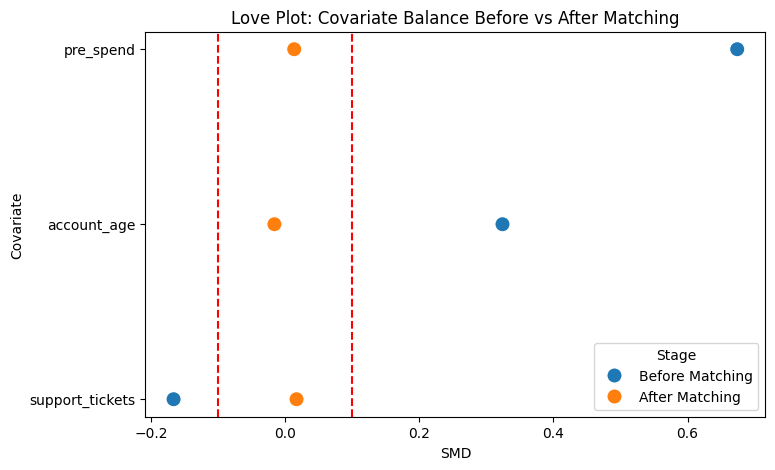

In [91]:
covariates = ['pre_spend', 'account_age', 'support_tickets']

def standardized_mean_diff(data, treatment, covariate):
    treat = data[data[treatment] == 1][covariate]
    control = data[data[treatment] == 0][covariate]
    smd = (treat.mean() - control.mean()) / np.sqrt((treat.var() + control.var()) / 2)
    return smd

smd_before = []
smd_after = []

for cov in covariates:
    smd_before.append(standardized_mean_diff(df_unmatched, 'subscriber', cov))
    smd_after.append(standardized_mean_diff(df_matched, 'subscriber', cov))

love_df = pd.DataFrame({
    'Covariate': covariates,
    'Before Matching': smd_before,
    'After Matching': smd_after
})

love_df = love_df.melt(id_vars='Covariate', var_name='Stage', value_name='SMD')

plt.figure(figsize=(8, 5))
sns.scatterplot(data=love_df, x='SMD', y='Covariate', hue='Stage', s=120)

plt.axvline(0.1, linestyle='--', color='red')
plt.axvline(-0.1, linestyle='--', color='red')

plt.title('Love Plot: Covariate Balance Before vs After Matching')
plt.show()